# Task 3.1: Two-Component Ablation

I keep the same dataset, seeds, and hyperparameters from Question 2 so that each ablation isolates one design choice at a time.

In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEEDS = [11, 23, 42, 57, 89]
DATA_NOISE = 0.22
LABEL_FLIP_RATE = 0.12
N_SAMPLES = 1200
TEST_SIZE = 0.20
VAL_SIZE = 0.20
GAMMA_GRID = [0.5, 1.0, 2.0]
SELECTED_GAMMA = 2.0
N_COMPONENTS = 500
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
FULL_S = -1.0
FAILURE_S = 0.25
PAPER_BANANA_ACCURACY = 89.84

cwd = Path.cwd()
if (cwd / "results").exists() and (cwd / "data").exists():
    PARTB_DIR = cwd
elif (cwd / "partB").exists():
    PARTB_DIR = cwd / "partB"
else:
    PARTB_DIR = cwd
RESULTS_DIR = PARTB_DIR / "results"
DATA_DIR = PARTB_DIR / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_dataset(seed, label_flip_rate=LABEL_FLIP_RATE, data_noise=DATA_NOISE):
    X, y = make_moons(n_samples=N_SAMPLES, noise=data_noise, random_state=42)
    X_train, X_temp, y_train_clean, y_temp = train_test_split(
        X, y, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=seed
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=seed
    )

    rng = np.random.default_rng(seed)
    flip_count = int(label_flip_rate * len(y_train_clean))
    flip_idx = np.sort(rng.choice(len(y_train_clean), size=flip_count, replace=False))

    y_train_observed = y_train_clean.copy()
    y_train_observed[flip_idx] = 1 - y_train_observed[flip_idx]
    was_flipped = np.zeros(len(y_train_clean), dtype=bool)
    was_flipped[flip_idx] = True

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        "seed": seed,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_clean": y_train_clean,
        "y_train_observed": y_train_observed,
        "y_val": y_val,
        "y_test": y_test,
        "was_flipped": was_flipped,
        "scaler": scaler,
    }


def validate_gamma(seeds=SEEDS, gammas=GAMMA_GRID, s=FULL_S):
    rows = []
    for gamma in gammas:
        for seed in seeds:
            split = build_dataset(seed)
            result = train_filtered_online_svm(
                split,
                gamma=gamma,
                s=s,
                n_components=N_COMPONENTS,
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )
            rows.append({
                "gamma": gamma,
                "seed": seed,
                "val_accuracy": result["val_accuracy"],
                "val_auc": result["val_auc"],
            })
    frame = pd.DataFrame(rows)
    summary = frame.groupby("gamma", as_index=False).agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        std_val_accuracy=("val_accuracy", "std"),
        mean_val_auc=("val_auc", "mean"),
    )
    return frame, summary


def decision_scores(artifacts, X_raw):
    X_scaled = artifacts["scaler"].transform(X_raw)
    Phi = artifacts["feature_map"].transform(X_scaled)
    return Phi @ artifacts["weights"]


def train_filtered_online_svm(
    split,
    gamma=SELECTED_GAMMA,
    s=FULL_S,
    n_components=N_COMPONENTS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    process_confident=False,
):
    feature_map = RBFSampler(gamma=gamma, n_components=n_components, random_state=split["seed"])
    Phi_train = feature_map.fit_transform(split["X_train_scaled"])
    Phi_val = feature_map.transform(split["X_val_scaled"])
    Phi_test = feature_map.transform(split["X_test_scaled"])

    y_pm = np.where(split["y_train_observed"] == 1, 1.0, -1.0)
    weights = np.zeros(Phi_train.shape[1], dtype=float)

    processed = 0
    skipped_left = 0
    skipped_right = 0

    start = time.perf_counter()
    for x_i, y_i in zip(Phi_train, y_pm):
        z = y_i * float(np.dot(weights, x_i))
        if z < s:
            skipped_left += 1
            continue
        if z > 1.0 and not process_confident:
            skipped_right += 1
            continue

        processed += 1
        weights *= (1.0 - learning_rate * weight_decay)
        if z <= 1.0:
            weights += learning_rate * y_i * x_i
    runtime = time.perf_counter() - start

    val_scores = Phi_val @ weights
    test_scores = Phi_test @ weights
    val_pred = (val_scores >= 0).astype(int)
    test_pred = (test_scores >= 0).astype(int)

    return {
        "seed": split["seed"],
        "gamma": gamma,
        "s": s,
        "process_confident": process_confident,
        "val_accuracy": accuracy_score(split["y_val"], val_pred),
        "val_auc": roc_auc_score(split["y_val"], val_scores),
        "test_accuracy": accuracy_score(split["y_test"], test_pred),
        "test_auc": roc_auc_score(split["y_test"], test_scores),
        "processed_examples": processed,
        "skipped_left": skipped_left,
        "skipped_right": skipped_right,
        "runtime_seconds": runtime,
        "weights": weights,
        "feature_map": feature_map,
        "scaler": split["scaler"],
        "split": split,
    }


def run_experiment(seeds=SEEDS, **kwargs):
    records = []
    artifacts = []
    for seed in seeds:
        split = build_dataset(seed)
        result = train_filtered_online_svm(split, **kwargs)
        records.append({
            "seed": seed,
            "test_accuracy": result["test_accuracy"],
            "test_auc": result["test_auc"],
            "processed_examples": result["processed_examples"],
            "skipped_left": result["skipped_left"],
            "skipped_right": result["skipped_right"],
            "runtime_seconds": result["runtime_seconds"],
        })
        artifacts.append(result)
    return pd.DataFrame(records), artifacts


def summarise_results(label, frame):
    return pd.DataFrame([
        {
            "method": label,
            "accuracy_mean": frame["test_accuracy"].mean(),
            "accuracy_std": frame["test_accuracy"].std(ddof=0),
            "auc_mean": frame["test_auc"].mean(),
            "auc_std": frame["test_auc"].std(ddof=0),
            "processed_mean": frame["processed_examples"].mean(),
            "processed_std": frame["processed_examples"].std(ddof=0),
            "runtime_mean": frame["runtime_seconds"].mean(),
            "runtime_std": frame["runtime_seconds"].std(ddof=0),
        }
    ])


def comparison_barplot(frame, metric_cols, title, output_path):
    melted = frame.melt(id_vars="method", value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=melted, x="metric", y="value", hue="method", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Method")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def save_seed42_dataset_csv(output_path):
    split = build_dataset(42)
    train_frame = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    train_frame["split"] = "train"
    train_frame["clean_label"] = split["y_train_clean"]
    train_frame["observed_label"] = split["y_train_observed"]
    train_frame["was_flipped"] = split["was_flipped"]

    val_frame = pd.DataFrame(split["X_val"], columns=["x1", "x2"])
    val_frame["split"] = "val"
    val_frame["clean_label"] = split["y_val"]
    val_frame["observed_label"] = split["y_val"]
    val_frame["was_flipped"] = False

    test_frame = pd.DataFrame(split["X_test"], columns=["x1", "x2"])
    test_frame["split"] = "test"
    test_frame["clean_label"] = split["y_test"]
    test_frame["observed_label"] = split["y_test"]
    test_frame["was_flipped"] = False

    full_frame = pd.concat([train_frame, val_frame, test_frame], ignore_index=True)
    full_frame.to_csv(output_path, index=False)
    return full_frame


def plot_dataset_overview(split, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    clean_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    clean_train["label"] = split["y_train_clean"]
    sns.scatterplot(data=clean_train, x="x1", y="x2", hue="label", palette="Set1", s=35, ax=axes[0])
    axes[0].set_title("Seed 42 training set before label flips")

    noisy_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    noisy_train["observed_label"] = split["y_train_observed"]
    noisy_train["was_flipped"] = split["was_flipped"]
    sns.scatterplot(
        data=noisy_train,
        x="x1",
        y="x2",
        hue="observed_label",
        style="was_flipped",
        palette="Set1",
        s=35,
        ax=axes[1],
    )
    axes[1].set_title("Seed 42 training set after 12% label flips")

    for ax in axes:
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def plot_decision_surface(artifacts, output_path, title):
    split = artifacts["split"]
    X_all = np.vstack([split["X_train"], split["X_test"]])
    y_all = np.concatenate([split["y_train_observed"], split["y_test"]])

    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = decision_scores(artifacts, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    classes = (scores >= 0).astype(float)
    ax.contourf(xx, yy, classes, levels=[-0.1, 0.5, 1.1], alpha=0.22, cmap="coolwarm")
    if np.ptp(scores) > 1e-9:
        ax.contour(xx, yy, scores, levels=[0.0], colors="black", linewidths=1.2)

    ax.scatter(split["X_train"][:, 0], split["X_train"][:, 1], c=split["y_train_observed"], cmap="coolwarm", s=22, alpha=0.75, label="Train")
    ax.scatter(split["X_test"][:, 0], split["X_test"][:, 1], c=split["y_test"], cmap="coolwarm", s=28, marker="x", label="Test")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


This is the same implementation block from Question 2. The ablations below are independent: when I remove one component, I keep the rest of the training setup fixed.

## Component Ablation 1

**Component being ablated:** the left flat-region filter `z < s`.  
In the full LASVM-I rule, this is the part that tries to ignore extreme mistakes instead of letting them keep shaping the model. Removing it gives a convex online hinge learner again, so this ablation directly tests whether the outlier-suppression idea helps on my toy setup.

In [2]:
full_runs, _ = run_experiment(gamma=SELECTED_GAMMA, s=FULL_S, process_confident=False)
left_removed_runs, _ = run_experiment(gamma=SELECTED_GAMMA, s=-999.0, process_confident=False)
left_compare = pd.concat([
    summarise_results('Full method', full_runs),
    summarise_results('Ablation 1: no left flat filter', left_removed_runs),
], ignore_index=True)
left_compare

                            method  accuracy_mean  ...  runtime_mean  runtime_std
0                      Full method       0.920000  ...      0.001174     0.000114
1  Ablation 1: no left flat filter       0.923333  ...      0.001139     0.000020

[2 rows x 9 columns]

This block compares the full method against the convex baseline created by disabling the left skip. The paper connection is direct: the removed component is exactly the part that comes from replacing hinge loss with the Ramp-loss view of severe outliers.

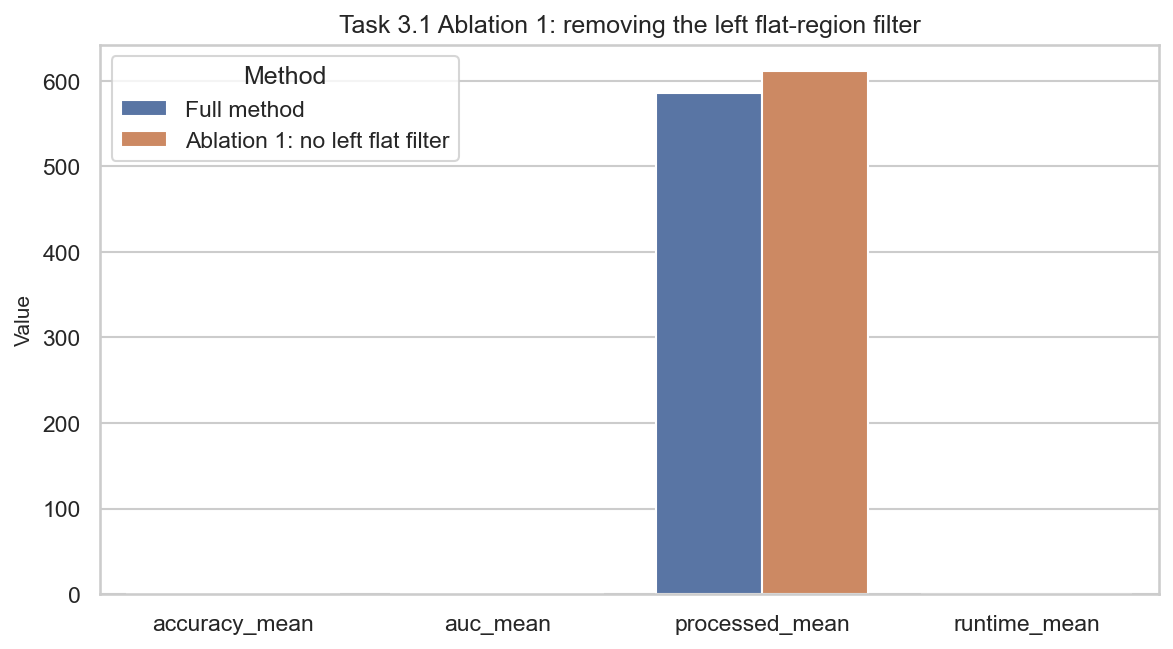

In [3]:
comparison_barplot(
    left_compare[['method', 'accuracy_mean', 'auc_mean', 'processed_mean', 'runtime_mean']],
    ['accuracy_mean', 'auc_mean', 'processed_mean', 'runtime_mean'],
    'Task 3.1 Ablation 1: removing the left flat-region filter',
    RESULTS_DIR / 'task_3_1_ablation_left_filter.png',
)

**Interpretation:** Removing the left flat-region filter raises the number of processed examples and gives a tiny accuracy increase on this particular toy setup. I take that as a sign that my data are only moderately noisy: there are some mislabeled points, but not enough extreme contamination for the filter to produce a clear accuracy win. Even so, the ablation is still informative because it shows the exact trade-off the paper is built around. The full method is more selective, but that selectivity can backfire when some of the skipped points are actually hard-but-useful examples. So for my dataset, the left filter looks more like a robustness safeguard than a guaranteed performance boost.

## Component Ablation 2

**Component being ablated:** the right flat-region skip `z > 1`.  
In the full method, confidently correct points are skipped because they already lie on the zero-loss side of the margin. Removing this skip does not radically change the decision boundary here, but it should make the learner spend extra computation on examples that are already safe.

In [4]:
right_removed_runs, _ = run_experiment(gamma=SELECTED_GAMMA, s=FULL_S, process_confident=True)
right_compare = pd.concat([
    summarise_results('Full method', full_runs),
    summarise_results('Ablation 2: no right flat skip', right_removed_runs),
], ignore_index=True)
right_compare

                           method  accuracy_mean  ...  runtime_mean  runtime_std
0                     Full method           0.92  ...      0.001174     0.000114
1  Ablation 2: no right flat skip           0.92  ...      0.001200     0.000026

[2 rows x 9 columns]

This ablation keeps the left filter active but forces the learner to process confidently correct points as well. That matches the paper's logic from the other flat side of the Ramp-loss curve: if a point is already comfortably correct, spending extra effort on it should mostly affect efficiency, not learning quality.

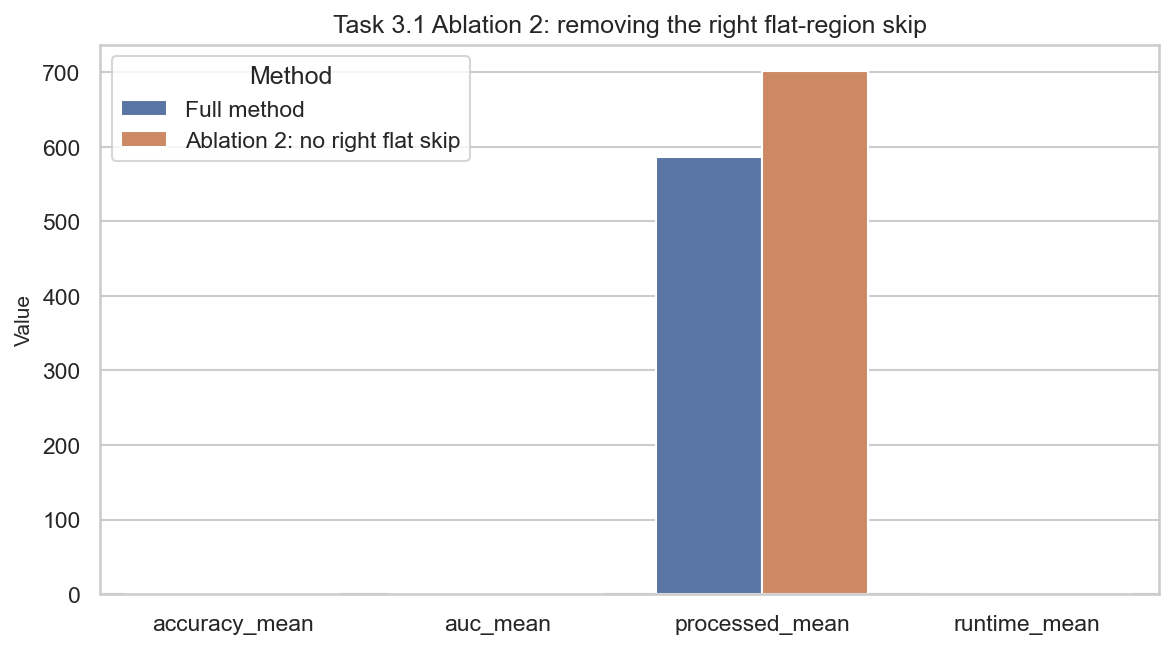

In [5]:
comparison_barplot(
    right_compare[['method', 'accuracy_mean', 'auc_mean', 'processed_mean', 'runtime_mean']],
    ['accuracy_mean', 'auc_mean', 'processed_mean', 'runtime_mean'],
    'Task 3.1 Ablation 2: removing the right flat-region skip',
    RESULTS_DIR / 'task_3_1_ablation_right_filter.png',
)

**Interpretation:** This second ablation behaves the way I expected. Accuracy and AUC stay effectively unchanged, but the number of processed examples rises a lot when I stop skipping confidently correct points. That tells me the right-side flat region is mostly an efficiency component in my simplified implementation rather than a major accuracy component. It is still important, though, because one of the paper's practical strengths is that it does not waste online updates on points that have already become uninformative. So this ablation supports the paper's computational intuition much more strongly than its predictive one.